In [ ]:
# Importamos las librerías necesarias para trabajar con datos

import pandas as pd      # Permite manipular tablas de datos
import numpy as np       # Permite realizar cálculos numéricos
import matplotlib.pyplot as plt  # Permite crear gráficos
import seaborn as sns    # Mejora la visualización de los gráficos

In [ ]:
# Cargamos el archivo CSV llamado customer.csv
# Esto convierte el archivo en una tabla que Python puede analizar

df = pd.read_csv("customer.csv")

# Mostramos las primeras filas para entender cómo están organizados los datos
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2010 08:26,3.39,17850.0,United Kingdom


In [ ]:
# Revisamos la información general del dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
# Convertimos la columna InvoiceDate de texto a formato fecha
# Esto permite analizar ventas por mes, día o año

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], dayfirst=True)

In [ ]:
# Contamos los valores nulos en cada columna
# Esto nos permite decidir qué limpiar

df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
# Eliminamos filas donde el cliente no está identificado
# Esto mejora la calidad del análisis de comportamiento de clientes

df = df.dropna(subset=["CustomerID"])

In [ ]:
# Verificamos si hay registros duplicados

df.duplicated().sum()

np.int64(5225)

In [ ]:
df = df.drop_duplicates()

In [ ]:
# Eliminamos facturas canceladas
# Estas no representan ventas reales

df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

In [ ]:
# Eliminamos precios incorrectos

df = df[df["UnitPrice"] > 0]

In [ ]:
# Calculamos el valor total de cada transacción
# Esto se usa para analizar ingresos

df["TotalSales"] = df["Quantity"] * df["UnitPrice"]

In [ ]:
# Agrupamos los datos por nombre del producto (Description)
# Luego sumamos la cantidad total vendida

top_products = df.groupby("Description")["Quantity"].sum()

# Ordenamos de mayor a menor
top_products = top_products.sort_values(ascending=False)

# Mostramos los 10 productos más vendidos
top_products.head(10)

,Quantity
Description,
"PAPER CRAFT , LITTLE BIRDIE",80995
MEDIUM CERAMIC TOP STORAGE JAR,77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
JUMBO BAG RED RETROSPOT,46078
WHITE HANGING HEART T-LIGHT HOLDER,36706
ASSORTED COLOUR BIRD ORNAMENT,35263
PACK OF 72 RETROSPOT CAKE CASES,33670
POPCORN HOLDER,30919
RABBIT NIGHT LIGHT,27153


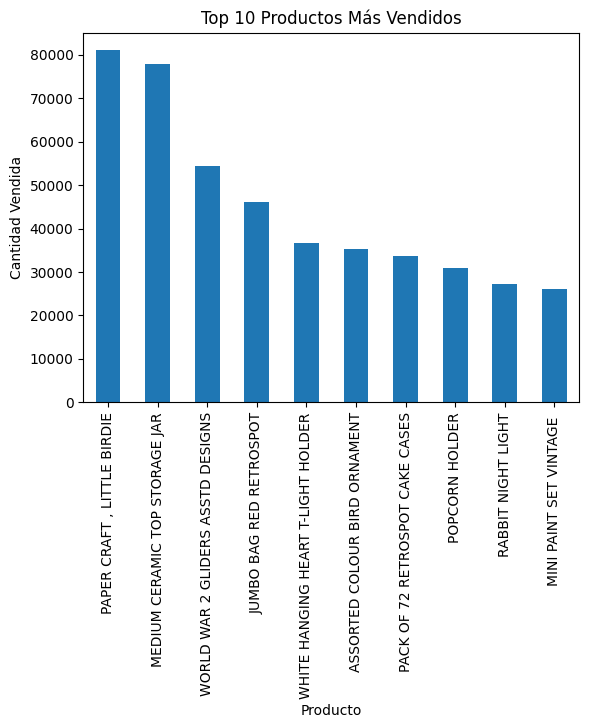

In [ ]:
# Graficamos los 10 productos más vendidos

top_products.head(10).plot(kind="bar")

plt.title("Top 10 Productos Más Vendidos")
plt.xlabel("Producto")
plt.ylabel("Cantidad Vendida")

plt.show()

In [ ]:
# Agrupamos las ventas por país

sales_country = df.groupby("Country")["TotalSales"].sum()

# Ordenamos de mayor a menor
sales_country = sales_country.sort_values(ascending=False)

# Mostramos los 10 países con más ventas
sales_country.head(10)

,TotalSales
Country,
United Kingdom,7285024.644
Netherlands,285446.340
EIRE,265262.460
Germany,228678.400
France,208934.310
Australia,138453.810
Spain,61558.560
Switzerland,56443.950
Belgium,41196.340


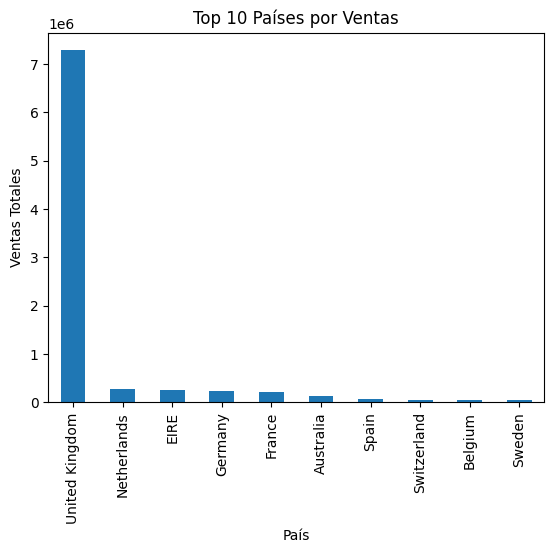

In [ ]:
# Gráfico de ventas por país

sales_country.head(10).plot(kind="bar")

plt.title("Top 10 Países por Ventas")
plt.xlabel("País")
plt.ylabel("Ventas Totales")

plt.show()

In [ ]:
# Agrupamos por cliente
# Sumamos todas las ventas que hizo cada cliente

top_customers = df.groupby("CustomerID")["TotalSales"].sum()

# Ordenamos de mayor a menor
top_customers = top_customers.sort_values(ascending=False)

# Mostramos los 10 clientes con más compras
top_customers.head(10)

,TotalSales
CustomerID,
14646.0,280206.02
18102.0,259657.30
17450.0,194390.79
16446.0,168472.50
14911.0,143711.17
12415.0,124914.53
14156.0,117210.08
17511.0,91062.38
16029.0,80850.84


In [ ]:
# Extraemos el mes de la fecha de compra

df["Month"] = df["InvoiceDate"].dt.month

In [ ]:
# Agrupamos las ventas por mes

sales_month = df.groupby("Month")["TotalSales"].sum()

# Ordenamos por mes
sales_month = sales_month.sort_index()

sales_month

,TotalSales
Month,
1,568101.310
2,446084.920
3,594081.760
4,468374.331
5,677355.150
6,660046.050
7,598962.901
8,644051.040
9,950690.202


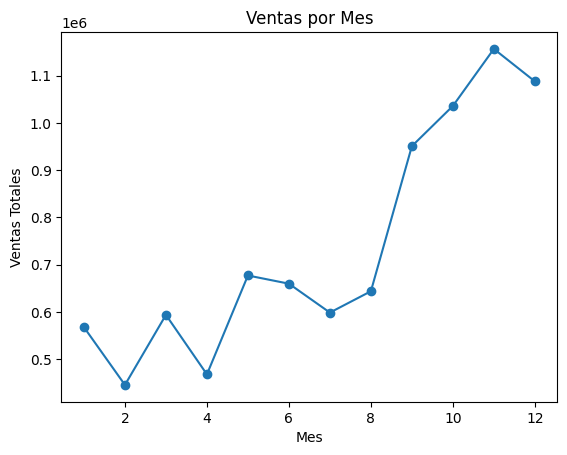

In [ ]:
# Gráfico de ventas por mes

sales_month.plot(kind="line", marker="o")

plt.title("Ventas por Mes")
plt.xlabel("Mes")
plt.ylabel("Ventas Totales")

plt.show()

In [ ]:
# Creamos una fecha de referencia para calcular recency
# Usamos el día siguiente a la última compra registrada

reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

In [ ]:
# Calculamos las métricas RFM

rfm = df.groupby("CustomerID").agg({

    "InvoiceDate": lambda x: (reference_date - x.max()).days,  # Recency
    "InvoiceNo": "count",                                      # Frequency
    "TotalSales": "sum"                                        # Monetary

})

In [ ]:
# Calculamos las métricas RFM

rfm = df.groupby("CustomerID").agg({

    "InvoiceDate": lambda x: (reference_date - x.max()).days,  # Recency
    "InvoiceNo": "count",                                      # Frequency
    "TotalSales": "sum"                                        # Monetary

})

In [ ]:
# Renombramos las columnas para que sean más claras

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [ ]:
# Creamos puntuaciones usando quantiles

rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])

In [ ]:
# Creamos una puntuación combinada

rfm["RFM_Score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,182,4310.00,5,5,5,555
12348.0,75,31,1797.24,2,3,4,234
12349.0,19,73,1757.55,4,4,4,444
12350.0,310,17,334.40,1,2,2,122


In [ ]:
# Creamos una puntuación combinada

rfm["RFM_Score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,115
12347.0,2,182,4310.00,5,5,5,555
12348.0,75,31,1797.24,2,3,4,234
12349.0,19,73,1757.55,4,4,4,444
12350.0,310,17,334.40,1,2,2,122


In [ ]:
# Filtramos clientes con mejor score

best_customers = rfm[rfm["RFM_Score"] == "555"]

best_customers.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12347.0,2,182,4310.00,5,5,5,555
12362.0,3,266,5226.23,5,5,5,555
12417.0,3,192,3649.10,5,5,5,555
12433.0,1,420,13375.87,5,5,5,555
12437.0,2,199,4951.41,5,5,5,555


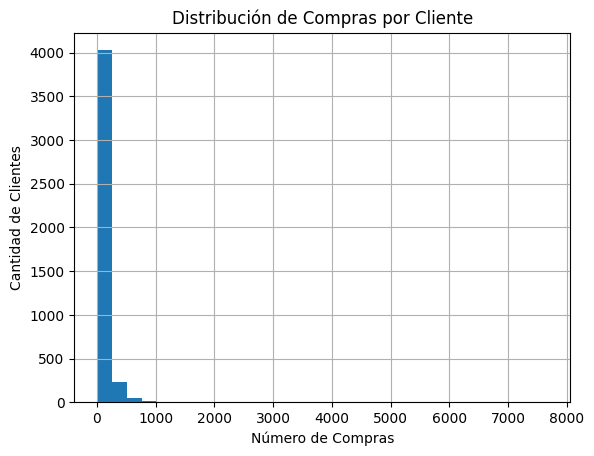

In [ ]:
# Visualizamos distribución de frecuencia

rfm["Frequency"].hist(bins=30)

plt.title("Distribución de Compras por Cliente")
plt.xlabel("Número de Compras")
plt.ylabel("Cantidad de Clientes")

plt.show()